# Basic processing pipeline for image-based profiles

The main objective of data processing is to get the data ready for downstream statistical analysis and machine learning. This means we want to nicely annotate the data with metadata of interest, to deal with any missing values, to try and adjust the data to remove technical variability (normalisation), and to get rid of features that add more noise than signal to our data. Data processing is usually a pipeline, where the output of each step serves as the input to the next step. 

Each step of the processing pipeline creates a different representation of the data, usually increasing data abstraction and refinement as we proceed. In this notebook, we will go from Level 3 to Level 5 data. 

CellProfiler is a software tool that can be used to generate phenotypic profiles from Cell Painting images. Here, a Cell Painting pipeline was used to extract profiles from the different images.


| **Data Description**                              | **Level** | **Details** |
| :------------------------------------------------ | :--------: | :----------- |
| **Images**                                        | Level 1 | Raw microscopy images captured from the Cell Painting assay. Each image corresponds to a single field of view in a specific well and channel. |
| **Single-cell profiles**                 | Level 2 | Per-cell morphological measurements extracted from images using for example *CellProfiler* or *Dino v2*|
| **Aggregated profiles with metadata information** | Level 3 | Single-cell profiles aggregated to the **well level** (e.g., median across all cells in a well) and annotated with **metadata** such as plate, well, and treatment. |
| **Normalized aggregated profiles**                | Level 4a | Well-level profiles normalized relative to **control wells** (e.g., DMSO) to correct for plate or batch effects. |
| **Normalized and feature-selected profiles**      | Level 4b | Normalized profiles with redundant or noisy features removed to retain only the **most informative and stable features**. |
| **Consensus profiles\***                            | Level 5 | Aggregation of replicate profiles to create a **final consensus signature** per perturbation or treatment. Used for reproducibility assessment and biological interpretation. |


\* In some analysis pipelines, a Level 6 aggregation is used to aggregate profiles at the compound level independently of the perturbation level (e.g. multi-concentration profiles).

## Imports

In [38]:
import pandas as pd
from pycytominer import normalize, feature_select, consensus

# Annotate well-level profiles (level 3)

In [39]:
# Read in profiles from each plate
data_list = []
plates = ["BR00127145", "BR00127146", "BR00127147", "BR00127148", "BR00127149"]
for plate in plates:
    data_tmp = pd.read_parquet('../../inputs/' + plate + '.parquet')
    data_list.append(data_tmp)
df_cellprofiler = pd.concat(data_list)
df_cellprofiler = df_cellprofiler.reset_index(drop = True)

In [40]:
# Read in compound metadata
df_compound_info = pd.read_csv("../../inputs/compound_info.csv")
df_compounds_wells_links = pd.read_csv("../../inputs/compound_well_map.csv")
df_compounds_annotations = pd.read_csv("../../inputs/perturbation_controls.csv")

In [41]:
# merge df_cellprofiler and df_compounds_wells_links based on common columns Metadata_Source Metadata_Plate Metadata_Well
df_cellprofiler_compounds = pd.merge(
    df_cellprofiler,
    df_compounds_wells_links,
    on=["Metadata_Source", "Metadata_Plate", "Metadata_Well"],
    how="inner"
)

In [42]:
# merge df_cellprofiler_compounds and df_compounds_wells_links based on common column Metadata_JCP2022
df_cellprofiler_compounds_infos = pd.merge(
    df_cellprofiler_compounds,
    df_compound_info,
    on=["Metadata_JCP2022"],
    how="inner"
)

In [43]:
# merge df_cellprofiler_compounds_infos and df_compounds_annotations based on common column Metadata_JCP2022
df_level3 = pd.merge(
    df_cellprofiler_compounds_infos,
    df_compounds_annotations,
    on=["Metadata_JCP2022"],
    how="left"
)

# Save level 3 data to outputs folder as csv file
df_level3.to_csv('../../outputs/df_level3.csv', index=False)

**Exercise** 
- How many unique compounds are included in this dataset? 
- How many replicates of each compound are there? 
- How are compound replicates arranged across the plates? Make a heatmap for each plate that shows how the compounds are plated (for easier visualisation purpose you can plot only one compound at a time). The heatmaps should have 384 cells, with rows and columns corresponding to the rows and columns of the physical plate.

In [44]:
# How many unique compounds are included in this dataset?
df_level3["Metadata_JCP2022"].nunique()

302

In [45]:
df_level3["Metadata_JCP2022"].value_counts().head(10)

Metadata_JCP2022
JCP2022_033924    320
JCP2022_102083     10
JCP2022_015955     10
JCP2022_046054     10
JCP2022_001036     10
JCP2022_013856     10
JCP2022_080920     10
JCP2022_105442     10
JCP2022_032771     10
JCP2022_002118     10
Name: count, dtype: int64

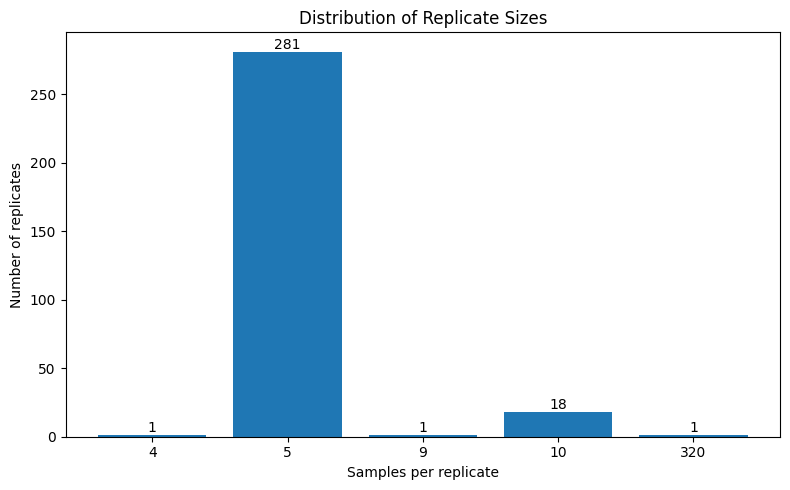

In [46]:
# Number of replicates for each replicate size
import matplotlib.pyplot as plt

replicate_counts = df_level3["Metadata_JCP2022"].value_counts()

freq = replicate_counts.value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(freq.index.astype(str), freq.values)

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Samples per replicate")
plt.ylabel("Number of replicates")
plt.title("Distribution of Replicate Sizes")
plt.tight_layout()
plt.show()

In [47]:
df_level3.columns

Index(['Metadata_Source', 'Metadata_Plate', 'Metadata_Well',
       'Cells_AreaShape_Area', 'Cells_AreaShape_BoundingBoxArea',
       'Cells_AreaShape_BoundingBoxMaximum_X',
       'Cells_AreaShape_BoundingBoxMaximum_Y',
       'Cells_AreaShape_BoundingBoxMinimum_X',
       'Cells_AreaShape_BoundingBoxMinimum_Y', 'Cells_AreaShape_Center_X',
       ...
       'Nuclei_Texture_Variance_RNA_5_01_256',
       'Nuclei_Texture_Variance_RNA_5_02_256',
       'Nuclei_Texture_Variance_RNA_5_03_256', 'Metadata_JCP2022',
       'Metadata_InChIKey', 'Metadata_InChI', 'Metadata_SMILES',
       'Metadata_pert_type', 'Metadata_Name', 'Metadata_modality'],
      dtype='object', length=4772)

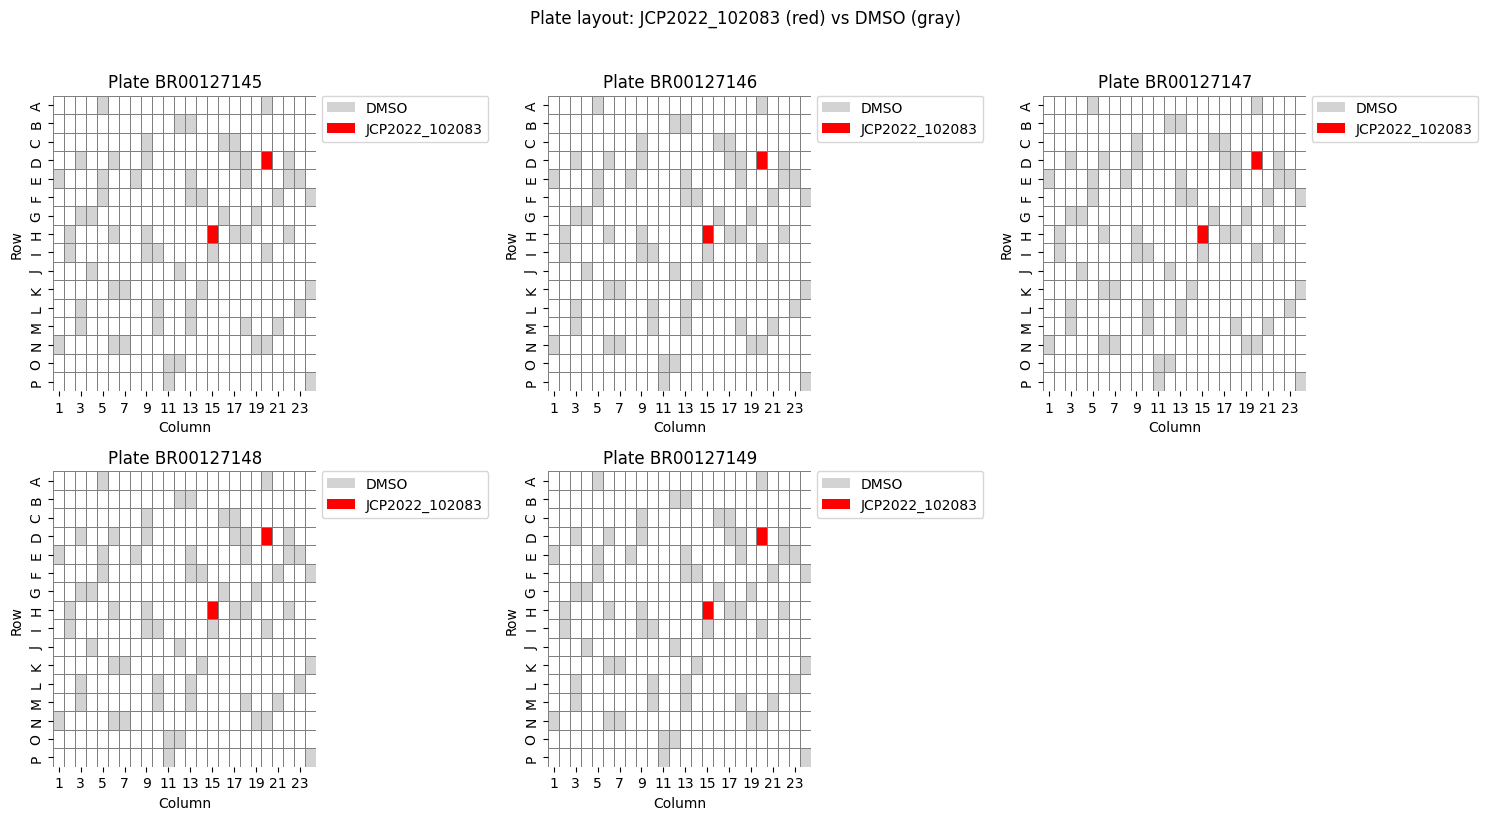

In [48]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ---------------------------
# Parameters
# ---------------------------
selected_compound = "JCP2022_102083"  # <-- change this
dmso = "JCP2022_033924"

# ---------------------------
# Prepare data
# ---------------------------
df = df_level3.copy()

df["Metadata_Row"] = (
    df["Metadata_Well"]
    .str.extract(r"([A-Za-z]+)")[0]
    .str.upper()
)

df["Metadata_Col"] = (
    df["Metadata_Well"]
    .str.extract(r"(\d+)")[0]
    .astype(int)
)

# 384-well plate layout
row_order = list("ABCDEFGHIJKLMNOP")
col_order = list(range(1, 25))

# 0 = other compounds
# 1 = DMSO
# 2 = selected compound
df["plot_code"] = 0

df.loc[
    df["Metadata_JCP2022"] == dmso,
    "plot_code"
] = 1

df.loc[
    df["Metadata_JCP2022"] == selected_compound,
    "plot_code"
] = 2

# ---------------------------
# Plot plates
# ---------------------------
plates = sorted(df["Metadata_Plate"].dropna().unique())

n_plates = len(plates)
n_cols = math.ceil(np.sqrt(n_plates))
n_rows = math.ceil(n_plates / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

cmap = ListedColormap([
    "white",      # other compounds
    "lightgray",  # DMSO
    "red"         # selected compound
])

for ax, plate in zip(axes.flat, plates):

    df_plate = df[df["Metadata_Plate"] == plate]

    plate_map = (
        df_plate.pivot_table(
            index="Metadata_Row",
            columns="Metadata_Col",
            values="plot_code",
            aggfunc="first"
        )
        .reindex(index=row_order, columns=col_order)
        .fillna(0)
    )

    sns.heatmap(
        plate_map,
        cmap=cmap,
        vmin=0,
        vmax=2,
        cbar=False,
        linewidths=0.5,
        linecolor="gray",
        ax=ax
    )

    ax.set_title(f"Plate {plate}")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

    legend_elements = [
        Patch(facecolor="lightgray", label="DMSO"),
        Patch(facecolor="red", label=selected_compound),
    ]

    ax.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0
    )

# Remove unused axes
for ax in axes.flat[n_plates:]:
    ax.axis("off")

fig.suptitle(
    f"Plate layout: {selected_compound} (red) vs DMSO (gray)",
    y=1.02
)

plt.tight_layout()
plt.show()

## Normalize (level 4a)

To ensure consistent comparisons across plates and experiments, **feature values are normalized** relative to control wells — typically **DMSO** for chemical perturbations. Normalization attempts to remove plate-to-plate and systematic technical variability, allowing biological differences to be more accurately captured.

In [49]:
# Normalize by plates
df_level4a_list = []
for plate in plates:
    df_level4a_plate = normalize(
        profiles=df_level3[df_level3["Metadata_Plate"] == plate],
        features="infer",
        meta_features="infer",
        samples="Metadata_Name == 'DMSO'",
        method="mad_robustize",
    )
    df_level4a_list.append(df_level4a_plate)

df_level4a = pd.concat(df_level4a_list).reset_index(drop=True)

In [22]:
# Save level 4a data to outputs folder as csv file
df_level4a.to_csv('../../outputs/df_level4a.csv', index=False)

**Exercise**
- Did normalisation change the amount of variability associated with plate in our dataset? Visualise just the negative control DMSO samples in two dimensions (ie. PCA or UMAP), before and after normalisation, with samples coloured by plate.

In [ ]:
# features 
features = df_level3 columns doesnt start with Metadata
df_level4a
dmso = "JCP2022_033924"
df_level3["Metadata_JCP2022"]

In [56]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

dmso = "JCP2022_033924"

# Filter DMSO rows
df_level3_dmso = df_level3[df_level3["Metadata_JCP2022"] == dmso].copy()
df_level4a_dmso = df_level4a[df_level4a["Metadata_JCP2022"] == dmso].copy()

# Select feature columns (exclude Metadata columns)
features_level3 = [c for c in df_level3_dmso.columns if not c.startswith("Metadata")]
features_level4a = [c for c in df_level4a_dmso.columns if not c.startswith("Metadata")]

# Prepare matrices
X3 = df_level3_dmso[features_level3]
X4 = df_level4a_dmso[features_level4a]

# Standardize
X3_scaled = StandardScaler().fit_transform(X3)
X4_scaled = StandardScaler().fit_transform(X4)
#X3_scaled = X3
#X4_scaled = X4


# Independent PCA
pca3 = PCA(n_components=2)
pcs3 = pca3.fit_transform(X3_scaled)

pca4 = PCA(n_components=2)
pcs4 = pca4.fit_transform(X4_scaled)

# PCA results
pca_level3 = df_level3_dmso.copy()
pca_level3["PC1"] = pcs3[:, 0]
pca_level3["PC2"] = pcs3[:, 1]

pca_level4a = df_level4a_dmso.copy()
pca_level4a["PC1"] = pcs4[:, 0]
pca_level4a["PC2"] = pcs4[:, 1]

print("Level3 explained variance:", pca3.explained_variance_ratio_)
print("Level4a explained variance:", pca4.explained_variance_ratio_)

Level3 explained variance: [0.51675314 0.18726666]
Level4a explained variance: [0.38750222 0.12210806]


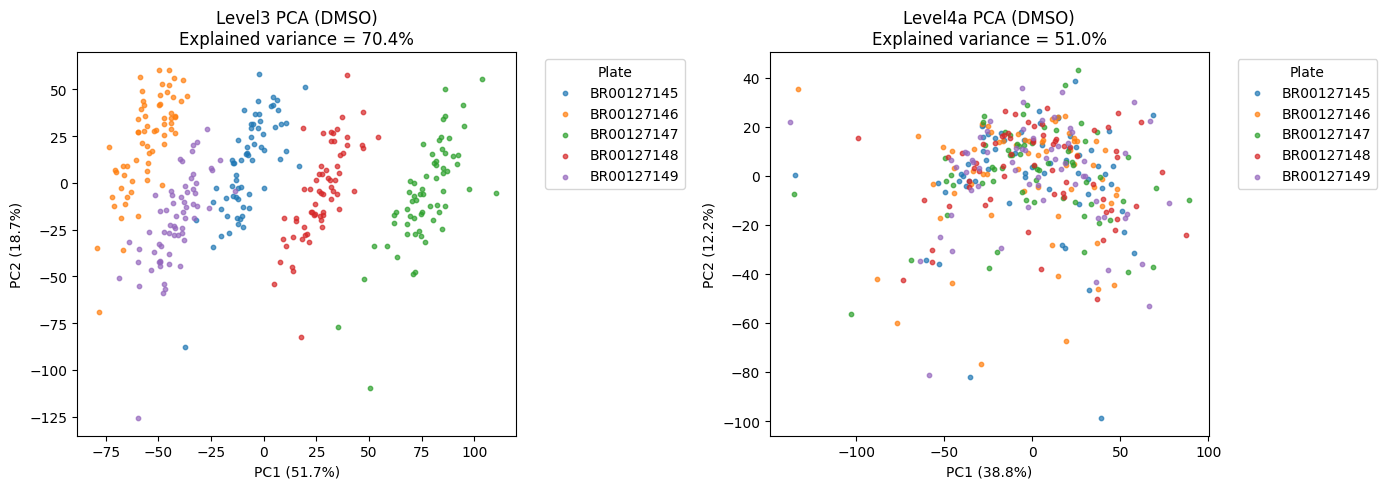

In [58]:
import matplotlib.pyplot as plt

plate_col = "Metadata_Plate"  # replace with your actual plate column

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----- Level 3 -----
for plate, group in pca_level3.groupby(plate_col):
    axes[0].scatter(
        group["PC1"],
        group["PC2"],
        s=10,
        alpha=0.7,
        label=str(plate)
    )

axes[0].set_title(
    f"Level3 PCA (DMSO)\nExplained variance = {(pca3.explained_variance_ratio_[:2].sum()*100):.1f}%"
)
axes[0].set_xlabel(f"PC1 ({pca3.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca3.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend(title="Plate", bbox_to_anchor=(1.05, 1), loc="upper left")

# ----- Level 4a -----
for plate, group in pca_level4a.groupby(plate_col):
    axes[1].scatter(
        group["PC1"],
        group["PC2"],
        s=10,
        alpha=0.7,
        label=str(plate)
    )

axes[1].set_title(
    f"Level4a PCA (DMSO)\nExplained variance = {(pca4.explained_variance_ratio_[:2].sum()*100):.1f}%"
)
axes[1].set_xlabel(f"PC1 ({pca4.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca4.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].legend(title="Plate", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Feature selection (level 4b)

CellProfiler extracts thousands of features, many of which can be **redundant or highly correlated**. To reduce noise and improve interpretability, **feature selection** is applied to retain only the most informative and non-redundant features. This step improves data quality and computational efficiency for downstream analysis.

In [23]:
feature_select_opts = [
    "variance_threshold",
    "drop_na_columns",
    "correlation_threshold",
    "blocklist",
    "drop_outliers",
]
df_level4b = feature_select(
    profiles=df_level4a, features="infer", samples="all", operation=feature_select_opts
)

In [24]:
# Save level 4b data to outputs folder as csv file
df_level4b.to_csv('../../outputs/df_level4b.csv', index=False)

**Exercise**
- Read [the documentation](https://pycytominer.readthedocs.io/en/stable/pycytominer.html#module-pycytominer.feature_select) to understand what each feature selection option is doing. 
- How many features does each feature selection option drop? Visualise which features each option drops with an upset plot.

# Consensus signature (level 5)

Finally, **well-level profiles** corresponding to the same **perturbation or treatment** (e.g., multiple wells, replicates, or concentrations) are **aggregated into consensus profiles**. These consensus profiles represent the **robust morphological signature** of each perturbation. Sometimes we prefer to use consensus profiles instead of replicate profiles for downstream analysis and visualisation.

In [25]:
df_level5 = consensus(
    profiles=df_level4b,
    replicate_columns=["Metadata_JCP2022"],
    features="infer",
    operation="modz",
)

/Users/ollitrault/Documents/projects/2026_DataScienceForLifeScientists_Training/cp-training/lib/python3.11/site-packages/pycytominer/cyto_utils/modz.py:154: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [26]:
# merge df_level5 and df_compounds_annotations based on common column Metadata_JCP2022
df_level5 = pd.merge(
    df_level5,
    df_compounds_annotations,
    on=["Metadata_JCP2022"],
    how="left"
)

# Save level 5 data to outputs folder as csv file
df_level5.to_csv('../../outputs/df_level5.csv', index=False)

In [32]:
df_level5

,Metadata_JCP2022,Cells_AreaShape_EulerNumber,Cells_AreaShape_Extent,Cells_AreaShape_MaximumRadius,Cells_AreaShape_Orientation,Cells_AreaShape_Zernike_1_1,Cells_AreaShape_Zernike_2_0,Cells_AreaShape_Zernike_2_2,Cells_AreaShape_Zernike_3_1,Cells_AreaShape_Zernike_3_3,...,Nuclei_Texture_InfoMeas1_DNA_10_01_256,Nuclei_Texture_InfoMeas2_AGP_3_02_256,Nuclei_Texture_InfoMeas2_DNA_10_03_256,Nuclei_Texture_InverseDifferenceMoment_AGP_10_01_256,Nuclei_Texture_InverseDifferenceMoment_DNA_10_03_256,Nuclei_Texture_InverseDifferenceMoment_RNA_10_03_256,Nuclei_Texture_SumVariance_RNA_10_01_256,Metadata_pert_type,Metadata_Name,Metadata_modality
0,JCP2022_000794,0.881888,-3.283020,-5.181463,-0.693973,-1.538441,-4.742888,1.114708,1.779054,-1.181462,...,-4.476324,-1.288912,3.322618,0.379173,-2.815993,0.647826,-0.574508,NaN,NaN,NaN
1,JCP2022_001036,0.676950,-0.193252,1.621191,-0.789116,-0.268256,-0.833730,-0.409720,0.048937,0.154339,...,-0.543275,-3.099220,0.655132,1.698192,-0.629725,1.393161,-0.980623,NaN,NaN,NaN
2,JCP2022_001275,-0.268107,0.407780,0.056508,-0.255188,0.025191,1.268643,-1.081036,-0.082914,0.750297,...,0.606763,-0.022665,-0.525418,0.728233,0.341216,0.804431,-0.738984,NaN,NaN,NaN
3,JCP2022_001890,0.738979,-5.782485,2.768373,0.029348,-0.280260,-9.427014,-1.712416,1.771081,-2.881955,...,-1.330497,2.271187,0.268864,-2.331185,-0.221517,-1.226987,3.074401,NaN,NaN,NaN
4,JCP2022_002118,0.426561,-2.923847,6.631440,0.197447,-2.067067,-4.106314,-0.575022,0.601895,-1.204755,...,-1.198537,-0.878925,1.406968,0.238938,-1.256263,0.245416,-0.215016,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,JCP2022_115963,1.052566,3.425415,-9.336345,0.246641,5.240881,0.704612,-0.466313,0.227309,5.280673,...,-3.947163,3.317567,2.579915,-4.913665,-1.682091,0.542095,-0.032787,NaN,NaN,NaN
298,JCP2022_116188,1.656441,-4.554161,-4.044363,1.836627,-1.056060,-6.808956,1.253640,1.413762,-2.192306,...,-0.629599,-3.491462,-0.046132,1.018828,0.114718,5.295665,-1.810581,NaN,NaN,NaN
299,JCP2022_116437,0.009437,0.458354,-0.163443,-0.165100,0.282820,0.530542,-0.062026,0.302744,0.297177,...,0.157544,-0.687704,-0.092596,0.804779,-0.240812,0.811996,-0.652802,NaN,NaN,NaN
300,JCP2022_116560,0.531140,-1.685101,4.258854,-1.058448,0.707670,-1.629007,-2.060303,1.279679,-0.629098,...,3.111725,-2.323452,-3.307382,0.296334,3.549154,-0.619424,0.865139,NaN,NaN,NaN
